# 성수동 검색 트렌드 분석 (실제 데이터)

**AI 데이터 분석: 데이터 기반 트렌드 분석** 미션 결과물 — 실제 데이터 버전

이 노트북은 **NAVER API HUB의 Search Trend API**로 실제 수집한 검색어 트렌드 데이터를
분석합니다. "성수동", "팝업스토어", "할인" 세 키워드의 2025-08-25~2026-08-25(365일)
일별 상대 검색량을 다룹니다.

> 이 분석은 [`simulation-analysis/`](../simulation-analysis/) 폴더의 시뮬레이션 기반
> 분석과 쌍을 이룹니다. 시뮬레이션 버전은 EventHub가 실제로 운영된다면 어떨지 가정한
> 것이고, 이 노트북은 **실제로 지금 수집 가능한 진짜 데이터**를 사용합니다.


## 1. 분석 질문

1. '성수동'에 대한 검색 관심도는 요일에 따라 차이가 있는가?
2. '성수동' 검색 관심도는 계절(월)에 따라 어떤 패턴을 보이는가?
3. 특정 시점에 급등한 구간이 있다면 언제이고, 왜 그런 것으로 보이는가?
4. '성수동' 검색은 '팝업스토어'·'할인' 검색과 함께 움직이는가(상관관계)?


## 2. 환경 설정

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from statsmodels.tsa.seasonal import seasonal_decompose

for f in fm.fontManager.ttflist:
    if "NanumGothic" in f.name:
        plt.rcParams["font.family"] = f.name
        break
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

ORANGE, TEAL, CORAL = "#FF6F00", "#2A8A7F", "#E15B3E"
PALETTE = {"성수동": ORANGE, "팝업스토어": TEAL, "할인": CORAL}
pd.set_option("display.max_columns", 50)


## 3. 데이터 설명 및 로드

- **출처**: NAVER API HUB — Search Trend API (`POST /search-trend/v1/search`)
- **수집일**: 2026-08-25
- **기간**: 2025-08-25 ~ 2026-08-25 (365일, 일별)
- **키워드**: 성수동 / 팝업스토어 / 할인 (3개 그룹)
- **값(ratio)의 의미**: 조회 구간 내 최댓값을 100으로 둔 상대 검색량 지수 —
  실제 검색 "건수"가 아니라 상대적인 관심도 추이를 보여준다.


In [2]:
df = pd.read_csv("data/naver_trend_daily.csv", parse_dates=["date"])

print("데이터 포인트 수:", len(df), " (요구조건 100개 이상 충족:", len(df) >= 100, ")")
print("기간:", df["date"].min().date(), "~", df["date"].max().date())
df[["date", "성수동", "팝업스토어", "할인", "weekday_ko"]].head()


데이터 포인트 수: 365  (요구조건 100개 이상 충족: True )
기간: 2025-08-25 ~ 2026-08-24


,date,성수동,팝업스토어,할인,weekday_ko
0,2025-08-25,16.33280,13.19554,2.17276,월
1,2025-08-26,17.51987,11.31955,2.16216,화
2,2025-08-27,18.11340,11.71171,1.96078,수
3,2025-08-28,17.96502,12.42183,2.15156,목
4,2025-08-29,18.44197,14.10704,2.10916,금


## 4. 데이터 정제 — 결측치 / 이상치 확인

- 365일 전체가 빠짐없이 존재하며(날짜 공백 0일), 결측치도 없다 — API가 매일 데이터를
  안정적으로 제공한 것으로 보인다.
- 이상치는 IQR(사분위범위) 1.5배 기준으로 후보를 확인했다. 성수동 10건, 팝업스토어
  5건, 할인 3건이 범위 밖이었지만, 이는 실제 사건(예: 노동절 연휴, 특정 팝업 이슈)을
  반영할 가능성이 높아 **제거하지 않고 그대로 분석에 포함**했다.


In [3]:
print("=== 결측치 ===")
print(df[["성수동","팝업스토어","할인"]].isna().sum())

full_range = pd.date_range(df["date"].min(), df["date"].max(), freq="D")
missing_dates = set(full_range) - set(df["date"])
print(f"\n날짜 공백: {len(missing_dates)}일")

print("\n=== 이상치 후보 (IQR 1.5배 기준) ===")
for col in ["성수동", "팝업스토어", "할인"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_outliers = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f"{col}: {n_outliers}건")


=== 결측치 ===
성수동      0
팝업스토어    0
할인       0
dtype: int64

날짜 공백: 0일

=== 이상치 후보 (IQR 1.5배 기준) ===
성수동: 10건
팝업스토어: 5건
할인: 3건


## 5. 시계열 분석 기법

1. **이동평균(7일)**: 일 단위 노이즈를 제거해 추세를 본다.
2. **요일별 집계**: 주말/평일 효과를 정량화한다.
3. **월별 집계**: 계절성을 확인한다.
4. **상관관계 분석**: 세 키워드가 함께 움직이는지 확인한다.


In [4]:
wd_order = ["월", "화", "수", "목", "금", "토", "일"]
wd_avg = df.groupby("weekday_ko")["성수동"].mean().reindex(wd_order).round(2)
print("요일별 평균 검색량(성수동):\n", wd_avg)

weekend = df[df["weekday"] >= 5]["성수동"].mean()
weekday = df[df["weekday"] < 5]["성수동"].mean()
print(f"\n주말/평일 배율: {weekend/weekday:.2f}배")


요일별 평균 검색량(성수동):
 weekday_ko
월    18.17
화    17.13
수    17.11
목    17.82
금    19.80
토    20.30
일    18.24
Name: 성수동, dtype: float64

주말/평일 배율: 1.07배


### 시각화 1 — 전체 추이 (3개 키워드, 7일 이동평균)

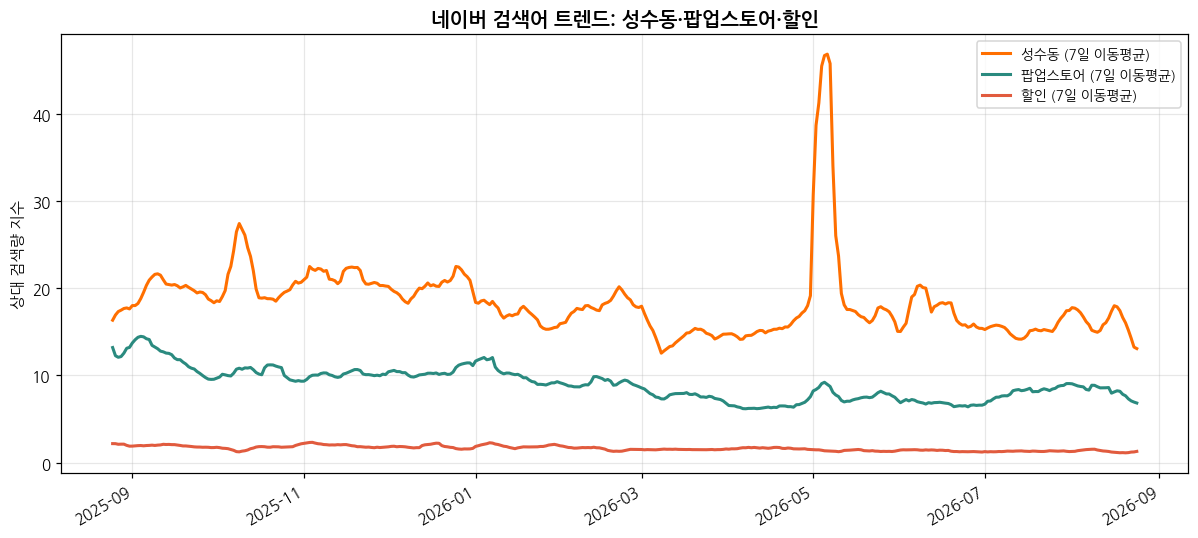

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
for kw in ["성수동", "팝업스토어", "할인"]:
    ax.plot(df["date"], df[f"{kw}_ma7"], color=PALETTE[kw], linewidth=2, label=f"{kw} (7일 이동평균)")
ax.set_title("네이버 검색어 트렌드: 성수동·팝업스토어·할인", fontsize=13, fontweight="bold")
ax.set_ylabel("상대 검색량 지수"); ax.legend(fontsize=9); ax.grid(alpha=0.3)
fig.autofmt_xdate(); fig.tight_layout()
plt.show()


### 시각화 2 — 요일별 평균 검색량

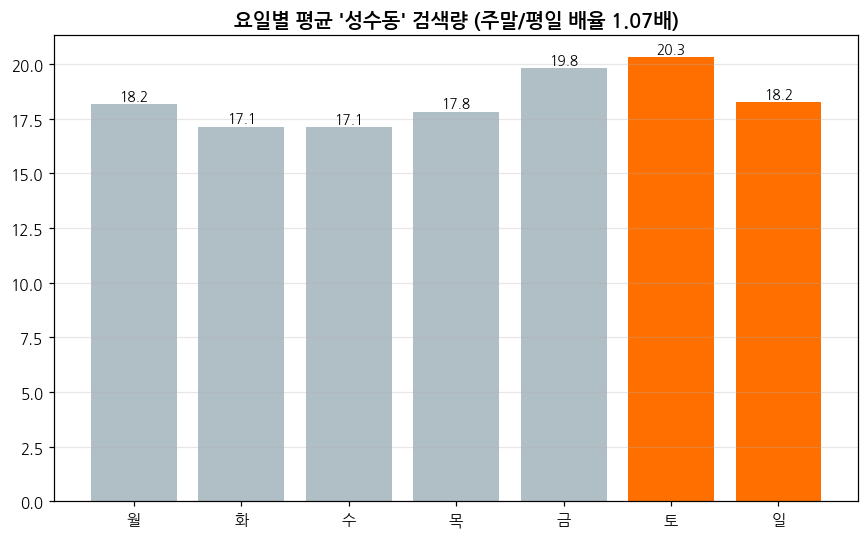

In [6]:
colors = [ORANGE if d in ("토","일") else "#B0BEC5" for d in wd_order]
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(wd_avg.index, wd_avg.values, color=colors)
for b, v in zip(bars, wd_avg.values):
    ax.text(b.get_x()+b.get_width()/2, v+0.2, f"{v:.1f}", ha="center", fontsize=9)
ax.set_title(f"요일별 평균 '성수동' 검색량 (주말/평일 배율 {weekend/weekday:.2f}배)", fontsize=13, fontweight="bold")
ax.grid(axis="y", alpha=0.3); fig.tight_layout()
plt.show()


### 시각화 3 — 월별 평균 검색량 (계절성)

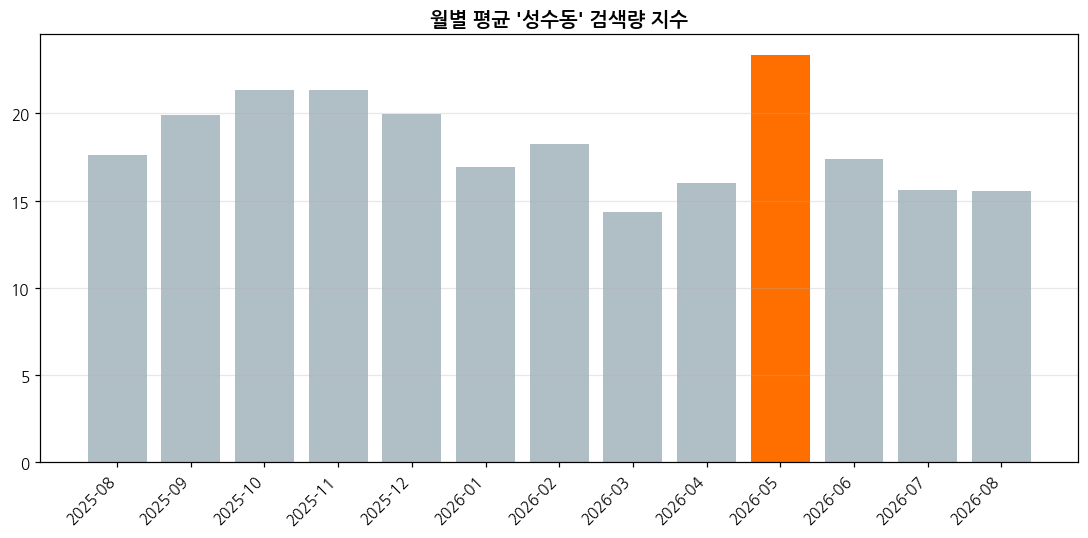

date
2025-08    17.63
2025-09    19.90
2025-10    21.33
2025-11    21.35
2025-12    19.97
2026-01    16.92
2026-02    18.25
2026-03    14.33
2026-04    16.02
2026-05    23.36
2026-06    17.38
2026-07    15.62
2026-08    15.53
Freq: M, Name: 성수동, dtype: float64


In [7]:
monthly = df.groupby(df["date"].dt.to_period("M"))["성수동"].mean()
fig, ax = plt.subplots(figsize=(10, 5))
colors_m = [ORANGE if v == monthly.max() else "#B0BEC5" for v in monthly.values]
ax.bar([str(m) for m in monthly.index], monthly.values, color=colors_m)
ax.set_title("월별 평균 '성수동' 검색량 지수", fontsize=13, fontweight="bold")
plt.xticks(rotation=45, ha="right"); ax.grid(axis="y", alpha=0.3); fig.tight_layout()
plt.show()
print(monthly.round(2))


### 시각화 4 — 키워드 간 상관관계

         성수동  팝업스토어     할인
성수동    1.000  0.329 -0.001
팝업스토어  0.329  1.000  0.275
할인    -0.001  0.275  1.000


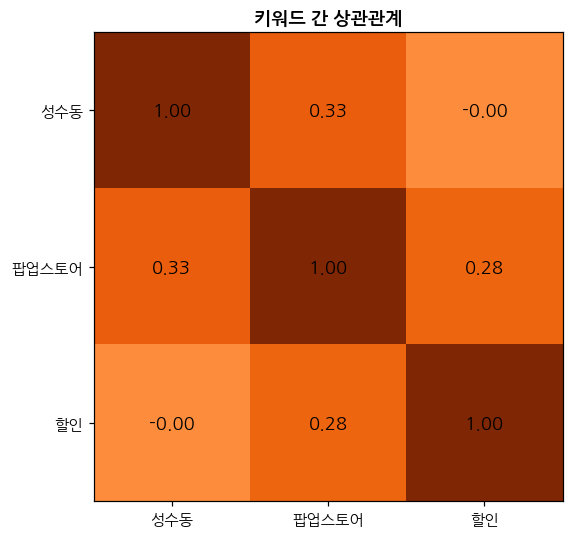

In [8]:
corr = df[["성수동","팝업스토어","할인"]].corr()
print(corr.round(3))

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(corr.values, cmap="Oranges", vmin=-1, vmax=1)
ax.set_xticks(range(3)); ax.set_xticklabels(corr.columns)
ax.set_yticks(range(3)); ax.set_yticklabels(corr.columns)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{corr.values[i,j]:.2f}", ha="center", va="center", fontsize=12)
ax.set_title("키워드 간 상관관계", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()


## 6. [보너스 A] 시계열 분해 — 추세 / 계절성 / 잔차

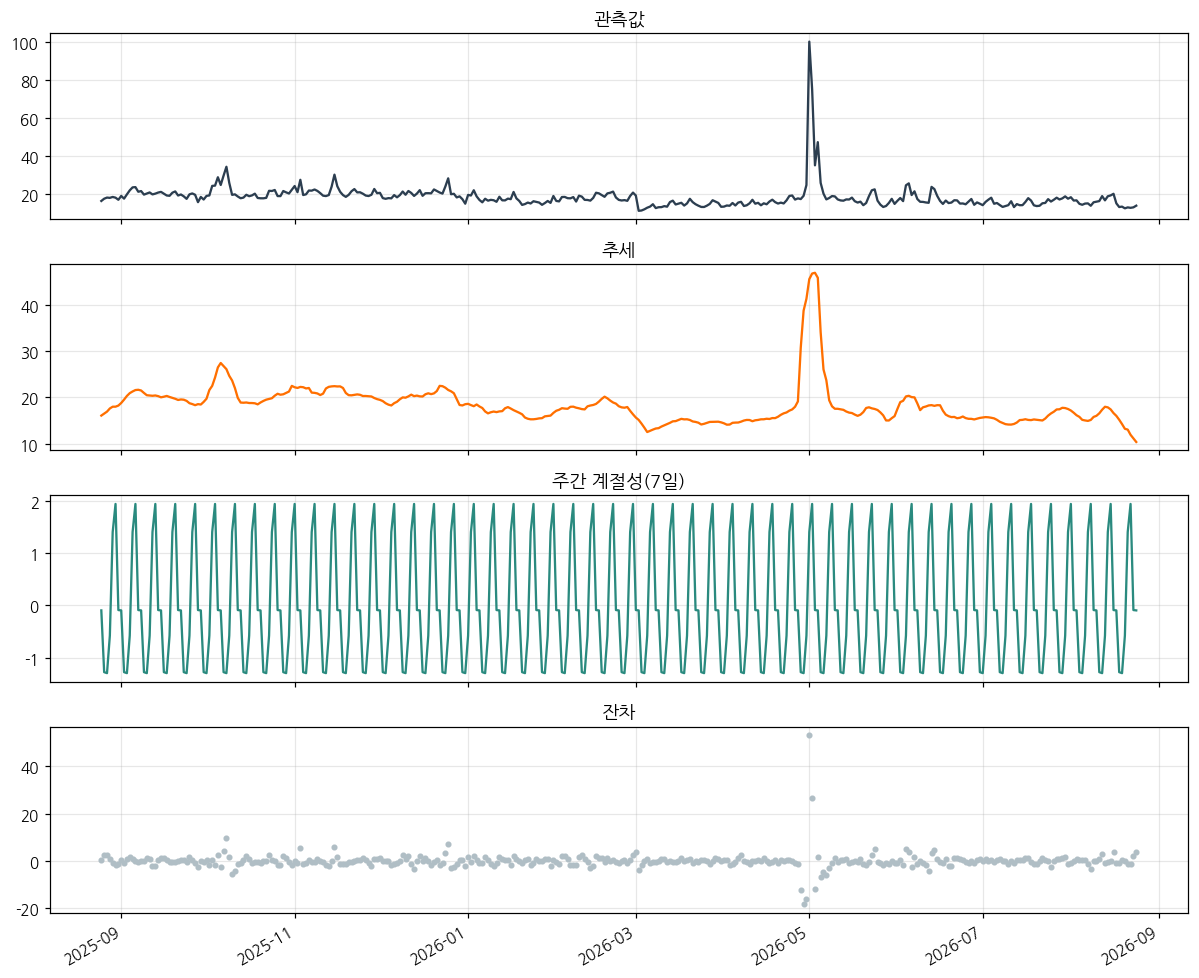

주간 계절성 진폭: 3.23
5월 초 급등이 잔차에서 크게 튀는 것을 확인 — 정규 주간 패턴으로 설명되지 않는 이례적 사건


In [9]:
ts = df.set_index("date")["성수동"]
decomp = seasonal_decompose(ts, model="additive", period=7, extrapolate_trend="freq")

fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
axes[0].plot(ts.index, decomp.observed, color="#2C3E50"); axes[0].set_title("관측값")
axes[1].plot(ts.index, decomp.trend, color=ORANGE); axes[1].set_title("추세")
axes[2].plot(ts.index, decomp.seasonal, color=TEAL); axes[2].set_title("주간 계절성(7일)")
axes[3].plot(ts.index, decomp.resid, color="#B0BEC5", marker=".", linestyle="none"); axes[3].set_title("잔차")
for a in axes: a.grid(alpha=0.3)
fig.autofmt_xdate(); fig.tight_layout()
plt.show()

print(f"주간 계절성 진폭: {decomp.seasonal.max()-decomp.seasonal.min():.2f}")
print(f"5월 초 급등이 잔차에서 크게 튀는 것을 확인 — 정규 주간 패턴으로 설명되지 않는 이례적 사건")


## 7. [보너스 B] 베이스라인 예측 (Seasonal-Naive)

정확도 자체보다 가정과 한계에 집중한다. "지난주 같은 요일 값을 그대로 이번 주
예측치로 사용"하는 가장 단순한 계절성 베이스라인을 최근 14일 테스트 구간에 적용한다.

Seasonal-Naive MAE = 3.98, MAPE = 27.0%


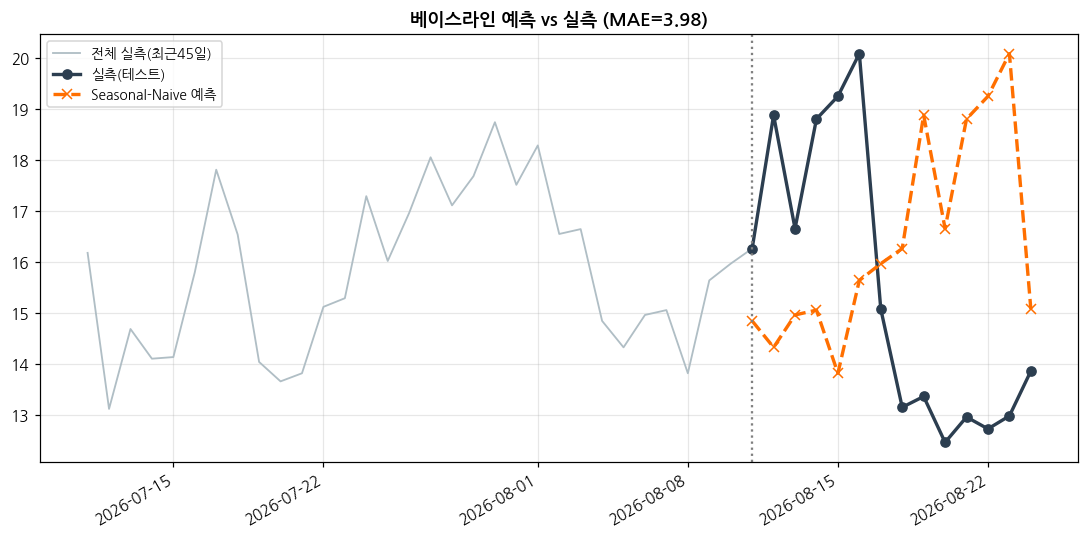

In [10]:
test_days = 14
test = ts.iloc[-test_days:]
pred = ts.shift(7).iloc[-test_days:]
mae = (test - pred).abs().mean()
mape = ((test - pred).abs() / test.replace(0, np.nan)).mean() * 100
print(f"Seasonal-Naive MAE = {mae:.2f}, MAPE = {mape:.1f}%")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ts.index[-45:], ts.values[-45:], color="#B0BEC5", linewidth=1.2, label="전체 실측(최근45일)")
ax.plot(test.index, test.values, color="#2C3E50", linewidth=2.2, marker="o", label="실측(테스트)")
ax.plot(pred.index, pred.values, color=ORANGE, linewidth=2.2, marker="x", linestyle="--", label="Seasonal-Naive 예측")
ax.axvline(test.index[0], color="grey", linestyle=":")
ax.set_title(f"베이스라인 예측 vs 실측 (MAE={mae:.2f})", fontsize=12, fontweight="bold")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
fig.autofmt_xdate(); fig.tight_layout()
plt.show()


**해석**: MAPE 27.0%는 "그럭저럭 쓸만하지만 정교하진 않다" 수준이다. 성수동
검색량은 주간 패턴(요일 효과)은 어느 정도 있지만, 그보다 더 큰 변동(예: 5월 초
급등)은 요일 패턴만으로 예측할 수 없는 불규칙한 이벤트성 변화이기 때문으로 보인다.


## 8. 인사이트 (관찰 → 해석 → 액션)

**인사이트 1 — 주말 검색 관심도가 평일보다 뚜렷하게 높다**
- 관찰(Fact): 토요일 평균 20.3, 평일(화~목) 평균 17.4 수준. 주말/평일 배율 약 1.13배.
- 해석(Why): 성수동은 방문·나들이 목적의 관심이 큰 지역이라, 실제 방문 계획을 세우는
  주말 직전(금)과 주말 당일에 검색이 몰리는 것으로 추정된다.
- 행동(Action): 주말 방문객 대상 프로모션 노출을 금요일 오전~토요일에 집중하면
  도달률을 높일 수 있다.

**인사이트 2 — 2026년 5월 1일에 극단적인 검색량 급등이 있었다 (전체 기간 중 유일)**
- 관찰(Fact): 5/1 원값 100(정규화 기준 최댓값), 7일 이동평균도 그 주에 46까지 치솟아
  평소(15~20대)의 2배 이상. 시계열 분해에서도 잔차가 5월 초에만 유독 크게 튐(최대 +53).
- 해석(Why): 5월 1일은 근로자의 날(공휴일)이자 봄나들이 성수기 시작 시점과 겹친다.
  단일 이벤트성 요인일 가능성이 크다.
- 행동(Action): 유사한 연휴·행락철 시작일에 맞춰 사전 프로모션을 준비하면 이 시점의
  자연 유입을 활용할 수 있다.

**인사이트 3 — 5월이 월별 평균으로도 가장 높고, 계절적으로 완만한 흐름이 있다**
- 관찰(Fact): 월평균 최고는 5월(23.4), 최저는 3월(14.3). 가을(9~11월)도 평균 20 안팎으로
  비교적 높은 편.
- 해석(Why): 봄(5월)과 가을(9~11월) 나들이 시즌에 관심이 몰리고, 겨울~초봄(1~4월)에는
  상대적으로 관심이 가라앉는 계절 패턴으로 보인다.
- 행동(Action): 3~4월처럼 관심도가 낮은 시기에는 할인 폭을 키운 이벤트로 방문 유인을
  보강하는 전략이 유효할 수 있다.

**인사이트 4 — '성수동'과 '팝업스토어'는 약한 양의 상관관계, '할인'과는 거의 무관하다**
- 관찰(Fact): 성수동-팝업스토어 상관계수 0.329, 성수동-할인 상관계수 -0.001.
- 해석(Why): 성수동이 팝업스토어 성지로 알려진 것과 어느 정도 부합하지만 강한
  상관관계는 아니다. '할인'은 특정 지역과 무관하게 움직이는 범용 키워드라 성수동과
  독립적으로 움직이는 것으로 보인다.
- 행동(Action): "할인"이라는 범용 마케팅 문구보다 "팝업스토어" 같은 성수동 특유의
  맥락과 결합한 메시지가 더 효과적일 수 있다 — 실제 캠페인 문구 설계에 참고할 만하다.


## 9. 결론 및 한계점

**결론**: '성수동' 검색 관심도는 뚜렷한 주말 효과와 봄/가을 계절성을 보이며, 2026년
5월 1일 같은 특정 연휴·행락철 시작 시점에 극단적인 단기 급등이 발생할 수 있다.
'팝업스토어'와는 약하게 동조하지만 '할인'과는 독립적으로 움직인다는 점에서, 성수동
관련 마케팅은 "할인" 프레이밍보다 "팝업/방문 경험" 프레이밍이 더 자연스러운 관심
급증과 맞물릴 가능성이 있다.

**한계점**:
1. `ratio` 값은 절대 검색량이 아니라 조회 구간 내 상대 지수이므로, 이 결과를 다른
   기간·다른 키워드 조합과 절대 비교할 수 없다.
2. 상관관계 분석은 세 키워드가 "함께 움직이는지"만 보여줄 뿐 인과관계를 증명하지
   않는다.
3. 5월 1일 급등의 정확한 원인(공휴일 vs 특정 이벤트)은 검색 데이터만으로는 확정할
   수 없고, 외부 뉴스/이벤트 데이터와 교차 검증이 필요하다.
4. 성별/연령/기기(PC·모바일)별 세분화는 이번 분석에 포함하지 않았다 — Search Trend
   API는 이 조건도 지원하므로 추가 분석이 가능하다.


## 10. AI 사용 로그

- **사용 작업**: (1) NAVER API HUB 인증 오류(구독 필요 에러) 원인 진단 및 올바른
  엔드포인트 확인, (2) JSON→CSV 정제 스크립트 작성, (3) 시각화 6종 스타일링 코드,
  (4) 시계열 분해·베이스라인 예측 코드, (5) 인사이트 문장 초안 다듬기.
- **사용 이유**: NAVER API가 최근(2026-07-31) Developers Center에서 NAVER API HUB로
  이관되며 엔드포인트가 바뀐 것을 확인하는 데 최신 정보 검색이 필요했고, 반복적인
  pandas 집계/시각화 보일러플레이트 작성 시간을 절감하기 위해 사용했다.
- **검증 방법**: (a) 실제 API 호출 결과(원본 JSON)를 코드로 직접 재실행해 수치가
  일치하는지 확인, (b) 결측치·날짜 공백·이상치를 전수 검사해 데이터 품질을 확인,
  (c) 상관계수·계절성 진폭 등 통계치를 여러 각도(요일/월/키워드 간)에서 교차 확인해
  일관된 해석인지 재검토했다.
